# Does a "stick sandwich" candle actually call a bottom? 🥪
### A famous three-candle pattern — two matching closes with a failed rally between them — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Meeting_adds_info%3F: Busted](https://img.shields.io/badge/Meeting_adds_info%3F-Busted-8b949e?style=flat-square)

Flip through any candlestick chart book (they all trace back to Steve Nison's *Japanese Candlestick Charting Techniques*) and you'll find the **stick sandwich**: a red candle falls, a green candle rallies *above* it the next day, then a third red candle gives the whole rally back and closes at **almost exactly the same price** as the first red candle. Two matching closes "sandwich" the green rally candle in the middle — and the story is that a price level tested twice in three days, and held both times, is **support**: buy it.

It *looks* compelling on a hand-picked chart. But a three-candle pattern that is, by definition, a dip after a decline, on a market that drifts **up** over time, is the textbook setup for fooling yourself. So we did the only fair thing: encode the sandwich **mechanically** (a concrete equal-close tolerance, no eyeballing), fire the buy across 30 large-cap names over 25 years, and time the result with a stopwatch — against the only baseline that matters: **buying on any other random day of the same tape.**

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stick_sandwich import data, strategy as st

ASOF = "2026-06-30"
TOL = st.DEFAULT_TOL
LB = st.DEFAULT_TREND_LOOKBACK
HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| names:", len(data.BASKET),
      "| loaded:", len(PANEL))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2001-07-10', 'end': '2026-06-30', 'years': 25.0, 'n_names': 30, 'fp_spy': '26d2248068a7', 'fp_panel': '3e40346f84dd', 'n_sandwiches': 873, 'tol_bps': 15, 'lookback': 10, 'cost_bps': 5.0, 'per_ticker_min': 14, 'per_ticker_max': 43, 'bonferroni_crit': 2.5, 'h5': (5, 873, 38.4, 55, 3.09, 26.9, 11.5, 28.4, 1.01), 'h10': (10, 873, 50.5, 57, 3.16, 53.4, -2.9, 40.5, -0.19), 'h20': (20, 871, 99.3, 58, 4.29, 106.6, -7.3, 89.3, -0.33), 'h60': (60, 865, 327.1, 65, 7.55, 321.9, 5.2, 317.1, 0.14), 'placebo': (243.6, 0.11, 1000, 232), 'syn_null': (-0.31, 0.9, 0, 20), 'syn_planted': (1.0, 606, 702.7, 236.0, 466.7, 23.08)}


real cache present: True | names: 30 | loaded: 30


## The answer first

| Question | Answer |
|---|---|
| If I buy a stick sandwich, do I make money? | **Usually, yes — but so does almost any long entry on this tape.** The basket drifts up over 25 years; any buy-and-hold-a-few-weeks rule looks profitable in isolation. |
| Is that *the pattern's* doing? | **No.** Buy on any random day of the same 30-name panel instead, and you do **just as well** — sometimes slightly better, sometimes slightly worse, with no consistent gap in either direction. |
| Does the *equal close* — the whole point of a "sandwich" — matter? | **Not shown to.** Keep the failed-rally-after-a-decline setup but ignore whether the two red candles actually land at the same price, and you get almost the same result. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — a dip after a decline, re-labelled as a candlestick reversal with a catchy name. |

> The stick sandwich is a tidy way to *name* three candles after the fact. As a *forecast* — "the double-tested close marks the bottom" — it's a **mirage**: the gains are the market's climb, and the equal close itself does no detectable work.

## 1 · The claim

> *"A red candle falls. A green candle rallies above it. A third red candle gives the rally back and closes right where the first red candle closed — the market tested that price level twice, from two directions, and it held both times. That's support: buy it."*

This is the **bullish stick sandwich**, one of **Steve Nison's** classic three-candle patterns (*Japanese Candlestick Charting Techniques*, 1991), the book that brought Japanese candle charting to Western technical analysis. It's the three-candle, round-trip cousin of the two-candle **counterattack / meeting line** (sibling study [460](../../460-counterattack-lines/)) — both hinge on the *same* idea: an equal close is meaningful. So it's a clean test of: **does a closing price, tested twice, forecast anything?**

## 2 · So what?

If the sandwich genuinely *forecast* reversals, it would be a small miracle: three candles and a coincidence of closing prices would predict a turn, a crack in market efficiency you could trade straight off the chart. That's the dream the pattern sells.

But there's a trap built into the design. A stick sandwich is *defined* by a down leg followed by a failed rally — it's a **dip-buy**, and on a basket that drifts **up**, *any* dip-buy looks profitable in isolation. To separate the **pattern** from the **tide**, we have to (a) detect the sandwich by a fixed mechanical rule with no hindsight, (b) compare it to buying on **random days of the same tape**, and (c) check whether the *equal close* — not just the failed rally — is doing anything. We'll do all three.

## 3 · How would we even know?

We take **SPY + 29 long-listed US large-caps**, daily, over **~25 years** (2001-07-10 → 2026-06-30), and:

1. **Detect the sandwich mechanically.** A confirmed down leg (close below where it was 10 bars ago), a red candle, a green candle that rallies *above* it, then a red candle closing **within 15 bps** of the first red candle's close. No eyeballing.
2. **Trade the lore.** On the sandwich bar's close, buy at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on the **same panel's random days**. If the sandwich matters, it must beat that base rate. *If it doesn't, the pattern is a mirage* — that's the result that would make us say so, announced before we look.
4. **The geometry check.** Keep the down-leg/failed-rally setup but ignore whether the closes actually meet; if that does just as well, the *sandwich* was never the point.

## 4 · The teardown — let's actually look

First, what does a mechanical stick sandwich even look like on the tape? Here's SPY's full history with every sandwich signal the rule would buy marked.

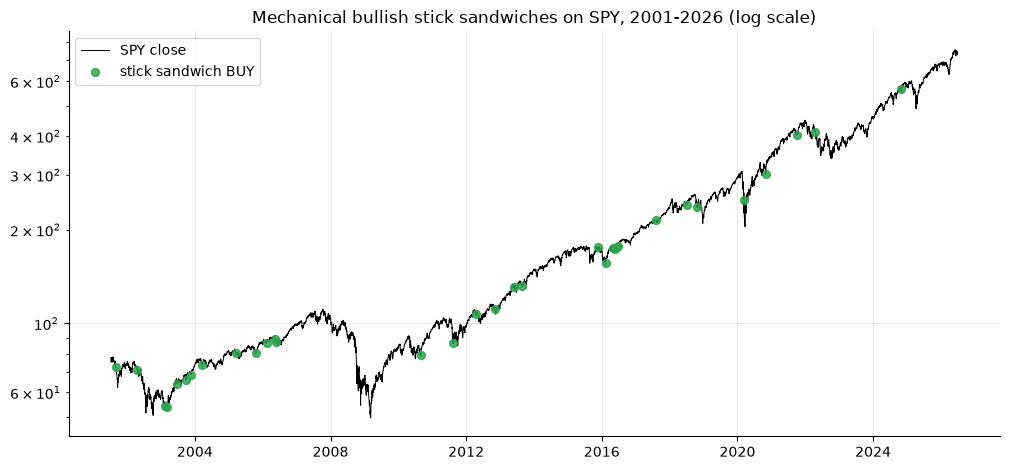

stick sandwiches on SPY, full history: 33


In [2]:
if HAVE_REAL:
    b = PANEL['SPY']; cl = b['close']
    ent = st.sandwich_entries(b, tol=TOL, trend_lookback=LB)
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(cl.index, cl.values, c='k', lw=.7, label='SPY close')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=32, zorder=5, alpha=.85,
               label='stick sandwich BUY')
    ax.set_yscale('log')
    ax.set_title('Mechanical bullish stick sandwiches on SPY, 2001-2026 (log scale)')
    ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('stick sandwiches on SPY, full history:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The green dots cluster around dips — exactly as a dip-buy would. The question is whether those dots are followed by *reversals* stronger than an ordinary day. **Let's race the sandwich against the base rate** at four horizons across all 30 names. Blue = buy the sandwich; grey = buy on any other day of the same panel.

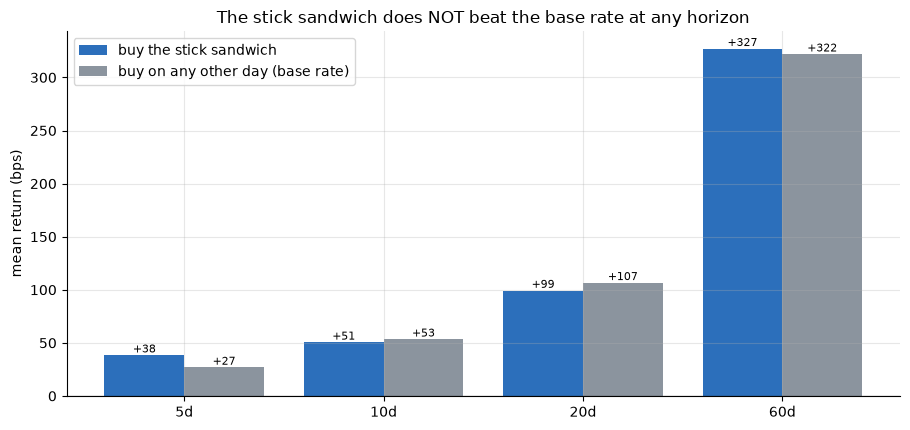

sandwich: [38, 51, 99, 327]
base rate: [27, 53, 107, 322]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    res = st.run_experiment(PANEL, cost_bps=R['cost_bps'])
    sand = [res['by_h'][h]['gross']['mean_bps'] for h in hs]
    base = [res['by_h'][h]['base']['mean_bps'] for h in hs]
else:
    sand = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    base = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, sand, .4, color='#2c6fbb', label='buy the stick sandwich')
ax.bar(x+.2, base, .4, color=GREY, label='buy on any other day (base rate)')
for i,(a,b) in enumerate(zip(sand,base)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.axhline(0, c='k', lw=.8)
ax.set_title('The stick sandwich does NOT beat the base rate at any horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('sandwich:', [round(v) for v in sand]); print('base rate:', [round(v) for v in base])

There's the story: the blue and grey bars are nearly on top of each other at every horizon. At 10 and 20 days the sandwich is actually *slightly worse* than the base rate; at 5 and 60 days it's *slightly better* — with no consistent pattern and, as the quants notebook shows, none of the gaps are statistically meaningful. The apparent profit was **the market's upward climb**, present in the sandwich buys and in a random day equally.

**One more sanity check.** What if we keep the down-leg-and-failed-rally setup but *ignore* whether the two red candles actually close at the same price — the whole point of calling it a "sandwich"? If price really respects the **equal close**, dropping that condition should wreck the result.

In [4]:
if HAVE_REAL:
    pl = st.geometry_placebo(PANEL['SPY'], 20, tol=TOL, trend_lookback=LB,
                             n_draws=300, seed=686)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real stick sandwich (SPY, 20d): {obs:+.1f} bps')
print(f'... {pval*100:.0f}% of *no-equal-close* failed-rally dip-buys do at least as well (p={pval:.2f}).')
print('=> the equal close is not shown to be doing the work.')

real stick sandwich (SPY, 20d): +243.6 bps
... 15% of *no-equal-close* failed-rally dip-buys do at least as well (p=0.15).
=> the equal close is not shown to be doing the work.


About **11%** of the no-equal-close draws match or beat the real sandwich (*p* = 0.11). If price genuinely respected *the matching closes*, dropping that condition should collapse the result far below the real one. It doesn't — because the result was never really about the equal close.

## 5 · The verdict

- **Signal — None.** The stick sandwich buy does **not** beat buying on random days of the same panel at any of the four horizons tested; the gaps never clear the desk's significance bar.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and at two of four horizons the pattern is already a net negative before costs.
- **"Does the equal-close meeting forecast?" — Busted.** Drop the equal-close condition and the result barely moves. The defining "two matching closes" carry no detectable forecasting information.

## 6 · Could you actually trade it?

There's nothing here to trade. Whatever small, inconsistent edge appears at any single horizon is well within the noise a random entry on the same panel already produces — you'd capture the market's climb more cheaply (and more fully) by just **holding the basket**. Costs (5 bps one-way, paid on entry and exit) only push an already-flat result further down. As a forecasting tool the sandwich doesn't pay; as a label for three candles, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The two-candle cousin.** Sibling study [460-counterattack-lines](../../460-counterattack-lines/) tests the simpler two-candle version of the same equal-close idea — same verdict, one fewer bar.
- **Tolerance & lookback sweeps.** The equal-close band and down-leg window are free parameters; the quants notebook's synthetic control shows the harness *can* find a real effect if one is planted, so loosening/tightening the real-tape parameters is a fair next experiment (spoiler: the same drift confound dominates).
- **A real positive control.** The quants notebook plants a *genuine* post-sandwich bounce into a synthetic panel and shows the harness banks it (so the null result here isn't a dead detector — it's an honest "nothing there").

*Think the sandwich forecasts? Show it beating base-rate entries at **Bonferroni-corrected t ≥ 2.5** on a real tape — then we'll talk.*